# Experiment 3: 3D Discrete DMP

This notebook extends the discrete DMP framework to three dimensions.
The core algorithm is the same as the 2D version but applied independently across x, y, and z.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Performance_measuring import test_dmp_performance

def dmp_discrete_3d_reproduce(
    pos, dt,
    kp=150.0, 
    kv=25.0, 
    alpha=5.0, 
    basis_num=40,
    speed=1.0,
    start_shift=None,
    goal_shift=None,
    spatial_scale=None,
    init_vel_scale=1.0,
    init_vel_offset=None
):   
    pos = np.asarray(pos) # checks demonstration is in correct form
    assert pos.ndim == 2 and pos.shape[0] == 3, "pos must be shape (3, T)"

    T = pos.shape[1] # number of intervals

    tau_demo = dt * T # duration of the demonstration (for learning)
    tau_new  = tau_demo / speed # new duration of demonstration

    vel = np.gradient(pos, axis=-1)/dt # velocity using derivative
    acc = np.gradient(vel, axis=-1)/dt # acceleration

    # Goal / start  shift and speed setup
    goal = pos[:, -1]
    demo_start = pos[:, 0]
    demo_goal  = pos[:, -1]

    if start_shift is None:
        start_shift = np.zeros(3)
    if goal_shift is None:
        goal_shift = np.zeros(3)

    start_shift = np.asarray(start_shift).reshape(3,)
    goal_shift  = np.asarray(goal_shift).reshape(3,)

    newStart = demo_start+start_shift # new start pos
    newGoal  = demo_goal +goal_shift # new goal pos

    if init_vel_offset is None:
        init_vel_offset = np.zeros(3)
    init_vel_offset = np.asarray(init_vel_offset).reshape(3,)

    demo_displacement = demo_goal - demo_start
    new_displacement  = newGoal - newStart

    if spatial_scale is None:
        spatial_scale = np.ones(3)
        for d in range(3):
            if abs(demo_displacement[d]) > 1e-8:
                spatial_scale[d] = new_displacement[d] / demo_displacement[d]



    # basis setup
    u = np.zeros(basis_num)
    c = np.zeros(basis_num)
    h = np.zeros(basis_num)

    # control center loactions of gaussians
    for i in range(basis_num):
        u[i] = (1.0/basis_num)*i
        c[i] = np.exp(-alpha * u[i])

    # control spread of gaussians
    for i in range(basis_num - 1):
        h[i] = 0.5 / ((0.65 * (c[i+1] - c[i]))**2) # controling 
    h[basis_num - 1] = h[basis_num - 2]

    #  Learning
    Phi = np.zeros(basis_num)
    Phi_total = np.zeros((T, basis_num))
    force = np.zeros((T, 3))

    s = 1.0
    for i in range(T):
        # canonical system 
        s = -alpha*s*dt/tau_demo+s

        addsum = 0.0
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum += Phi[b]
        Phi = Phi / addsum * s
        Phi_total[i, :] = Phi

        # target forcing term
        force[i, :] = (tau_demo*tau_demo)*acc[:, i] - kp*(goal - pos[:, i]) + tau_demo*kv*vel[:, i]

    trainPattern = np.matmul(np.linalg.pinv(Phi_total), force)  # (basis_num, 3)


    # setup for reconstruction
    T_new = int(np.round(tau_new / dt)) # note the use tau_new so that the reconstruction happens at the wanted speed

    DMP_pos = np.zeros((3, T_new))
    DMP_vel = np.zeros((3, T_new))
    DMP_acc = np.zeros((3, T_new))

    DMP_pos[:, 0] = newStart 
    DMP_vel[:, 0] = init_vel_scale * vel[:, 0] + init_vel_offset

    s = 1.0
    for i in range(T_new - 1):
        s = -alpha*s*dt/tau_new+s
        addsum = 0.0
        
        for b in range(basis_num):
            Phi[b] = np.exp(-h[b] * (s - c[b])**2)
            addsum = addsum + Phi[b]

        newForce = np.matmul(Phi / addsum, trainPattern) * s * spatial_scale

        # transformation system
        DMP_acc[:, i] = (kp*(newGoal - DMP_pos[:, i]) - tau_new*kv*DMP_vel[:, i] + newForce) / (tau_new**2)
        DMP_pos[:, i+1] = DMP_pos[:, i] + DMP_vel[:, i] * dt
        DMP_vel[:, i+1] = DMP_vel[:, i] + DMP_acc[:, i] * dt

    return DMP_pos, DMP_vel, DMP_acc, trainPattern, tau_new, newStart, newGoal



ModuleNotFoundError: No module named 'Performance_measuring'

## Test 1: Basic reproduction


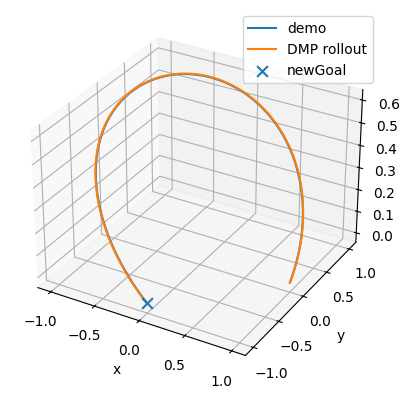

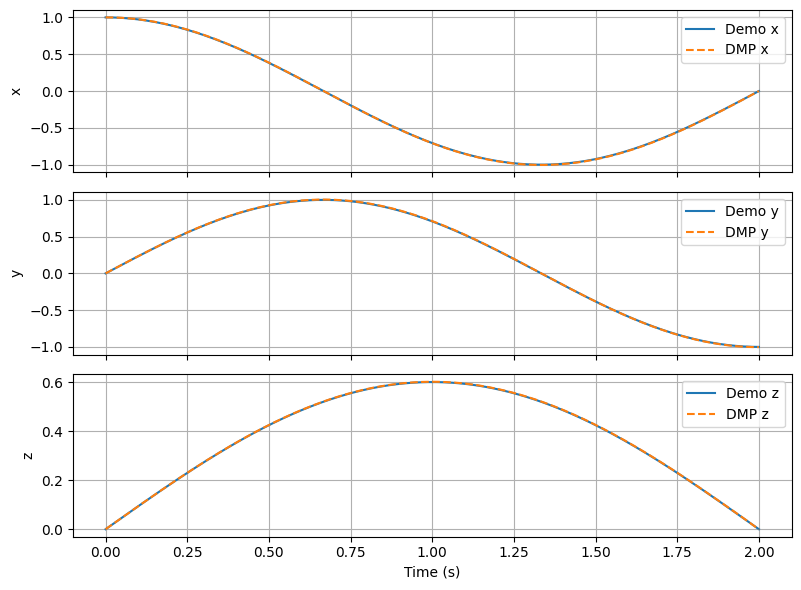

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gen_3d_discrete_demo(dt=0.005, tau=2.0, Axy=1.0, z_amp=0.6):
    T = int(np.round(tau / dt))
    t = np.linspace(0, tau, T)

    u = t / tau 

    x = Axy * np.cos(1.5*np.pi*u)
    y = Axy * np.sin(1.5*np.pi*u)
    z = z_amp * np.sin(np.pi*u)

    pos = np.vstack([x, y, z]) 
    return pos, t

dt = 0.005
pos, t_demo = gen_3d_discrete_demo(dt=dt, tau=2.0, Axy=1.0, z_amp=0.6)

vel = np.gradient(pos, axis=-1) / dt
acc = np.gradient(vel, axis=-1) / dt

# reproduction

DMP_pos, DMP_vel, DMP_acc, W, newTau, newStart, newGoal = dmp_discrete_3d_reproduce(
    pos, dt)

# visualization
newLen = DMP_pos.shape[1]
t_rep = np.linspace(0, newTau, newLen)

# 3D trajectory
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot(pos[0], pos[1], pos[2], label="demo")
ax.plot(DMP_pos[0], DMP_pos[1], DMP_pos[2], label="DMP rollout")
ax.scatter(newGoal[0], newGoal[1], newGoal[2], marker="x", s=60, label="newGoal")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend()
plt.show()

# per-axis position over time
labels = ["x", "y", "z"]
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
for j, ax in enumerate(axes):

    ax.plot(t_demo, pos[j], label=f"Demo {labels[j]}")
    ax.plot(t_rep, DMP_pos[j], label=f"DMP {labels[j]}", linestyle='--')

    ax.set_ylabel(labels[j])
    ax.legend()
    ax.grid(True)
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()


## Test 2 — Complex trajectory

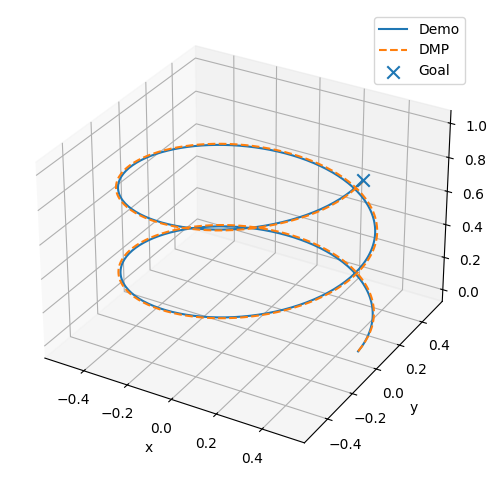

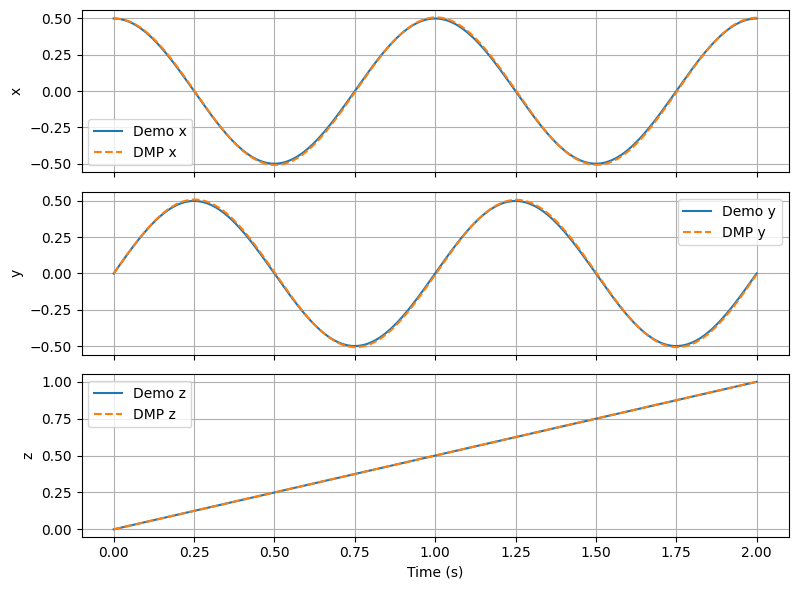

In [ ]:
def gen_helix(dt=0.005, tau=2.0, radius=0.5, z_height=1.0, turns=2.0):
    T = int(np.round(tau / dt))
    t = np.linspace(0, tau, T)
    u = t / tau

    angle = turns * 2 * np.pi * u
    x = radius * np.cos(angle)
    y = radius * np.sin(angle)
    z = z_height * u

    return np.vstack([x, y, z]), t

pos_helix, t_demo_helix = gen_helix(dt=dt)

DMP_pos_h, DMP_vel_h, DMP_acc_h, W_h, tau_h, start_h, goal_h = dmp_discrete_3d_reproduce(
    pos_helix, dt
)

# visualization
newLen = DMP_pos_h.shape[1]
t_roll = np.linspace(0, tau_h, newLen)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(pos_helix[0], pos_helix[1], pos_helix[2], label="Demo")
ax.plot(DMP_pos_h[0], DMP_pos_h[1], DMP_pos_h[2], label="DMP", linestyle='--')
ax.scatter(*goal_h, marker="x", s=80, label="Goal")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
for j, label in enumerate(["x", "y", "z"]):
    axes[j].plot(t_demo_helix, pos_helix[j], label=f"Demo {label}")
    axes[j].plot(t_roll, DMP_pos_h[j], label=f"DMP {label}", linestyle='--')
    axes[j].set_ylabel(label); axes[j].legend(); axes[j].grid(True)
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## Test 3 - Invariance cases

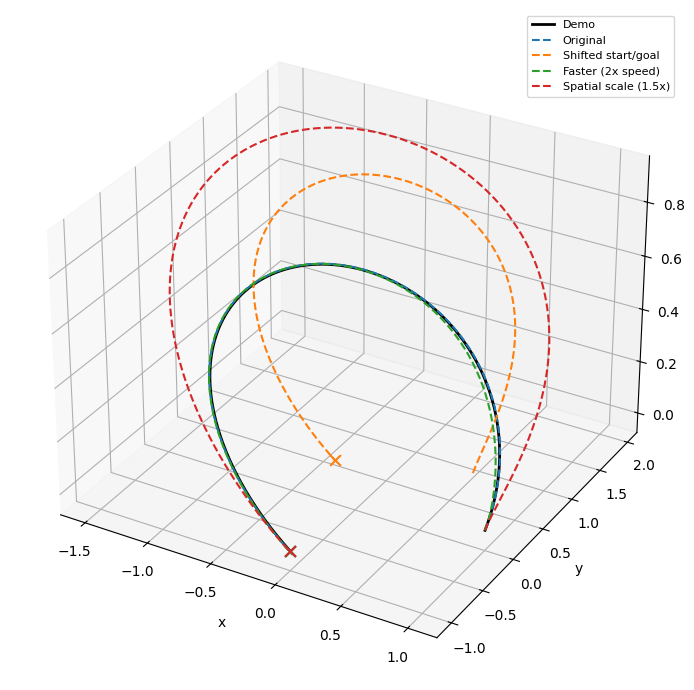

In [ ]:
invariance_cases = [ # cases library for testing different invariances
{"label": "Original",
 "speed": 1.0,
 "start_shift": [0, 0, 0],
 "goal_shift": [0, 0, 0],
 "spatial_scale": [1, 1, 1]},

{"label": "Shifted start/goal",
 "speed": 1.0,
 "start_shift": [-0.1, 0.0, 0.2],
 "goal_shift": [0.2, 0.3, 0.3],
 "spatial_scale": [1, 1, 1]},

{"label": "Faster (2x speed)",
 "speed": 2.0,
 "start_shift": [0, 0, 0],
 "goal_shift": [0, 0, 0],
 "spatial_scale": [1, 1, 1]},

{"label": "Spatial scale (1.5x)",
 "speed": 1.0,
 "start_shift": [0, 0, 0],
 "goal_shift": [0, 0, 0],
 "spatial_scale": [1.5, 1.5, 1.5]}
]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot(DMP_pos[0], DMP_pos[1], DMP_pos[2], 'k-', linewidth=2, label="Demo")

for tc in invariance_cases:
    DMP_pos_i, _, _, _, tau_i, start_i, goal_i = dmp_discrete_3d_reproduce(
        DMP_pos, dt,
        speed=tc["speed"],
        start_shift=tc["start_shift"],
        goal_shift=tc["goal_shift"],
        spatial_scale=tc["spatial_scale"],
    )
    ax.plot(DMP_pos_i[0], DMP_pos_i[1], DMP_pos_i[2], linestyle='--', label=tc["label"])
    ax.scatter(*goal_i, marker="x", s=60)

ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

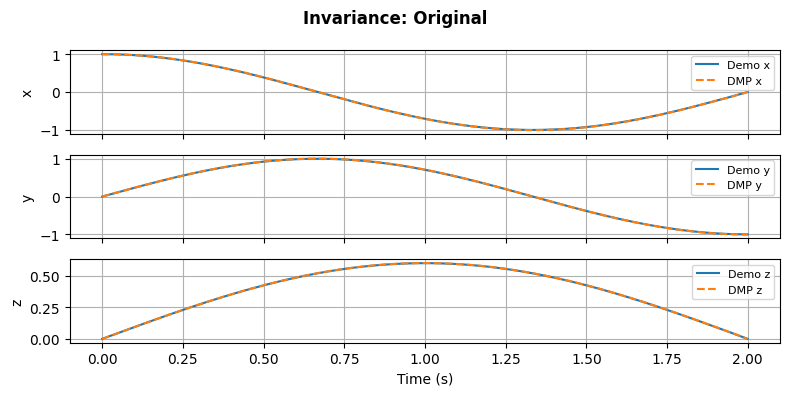

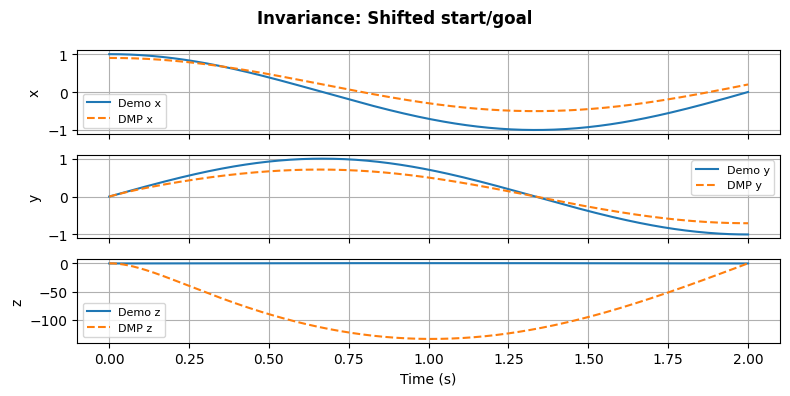

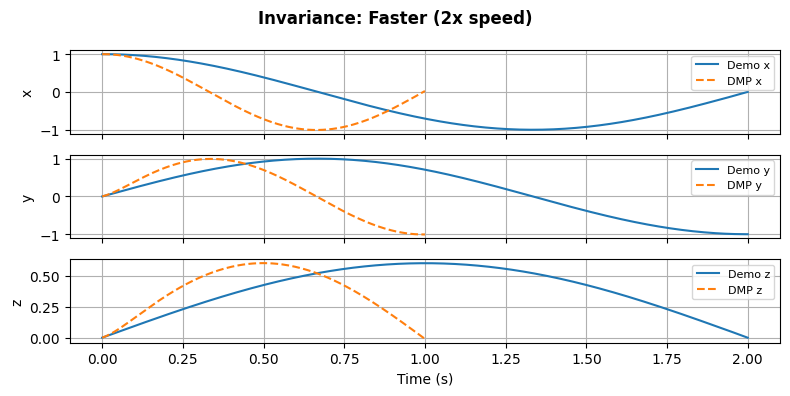

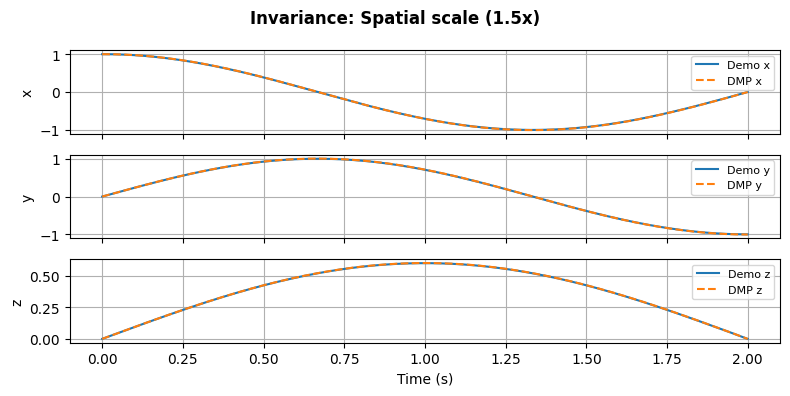

In [ ]:
# per-axis time plots for each invariance case
for tc in invariance_cases:
    DMP_pos_i, _, _, _, tau_i, start_i, goal_i = dmp_discrete_3d_reproduce(
        DMP_pos, dt,
        speed=tc["speed"],
        start_shift=tc["start_shift"],
        goal_shift=tc["goal_shift"],
    )
    T_i = DMP_pos_i.shape[1]
    t_i = np.linspace(0, tau_i, T_i)

    fig, axes = plt.subplots(3, 1, figsize=(8, 4), sharex=True)
    labels = ["x", "y", "z"]
    for j, ax in enumerate(axes):
        ax.plot(t_demo, DMP_pos[j], label=f"Demo {labels[j]}")
        ax.plot(t_i, DMP_pos_i[j], label=f"DMP {labels[j]}", linestyle='--')
        ax.set_ylabel(labels[j]); ax.legend(fontsize=8); ax.grid(True)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(f"Invariance: {tc['label']}", fontweight='bold')
    plt.tight_layout()
    plt.show()

## Performance Evaluation

Metrics for Test 1 (swirl reproduction) and Test 2 (helix reproduction),
plus the invariance cases compared against the original demo.

In [ ]:
print("Test 1")
_, t1 = test_dmp_performance(pos, DMP_pos)
for k, v in t1.items():
    print(f"  {k}: {v}")

print()
print("Test 2")
_, t2 = test_dmp_performance(pos_helix, DMP_pos_h)
for k, v in t2.items():
    print(f"  {k}: {v}")

print()
print("Invariance")
for tc in invariance_cases:
    DMP_pos_i, _, _, _, tau_i, start_i, goal_i = dmp_discrete_3d_reproduce(
        pos, dt,
        speed=tc["speed"],
        start_shift=tc["start_shift"],
        goal_shift=tc["goal_shift"],
    )
    goal_err = np.linalg.norm(DMP_pos_i[:, -1] - goal_i)
    print(f"  {tc['label']}  goal error: {goal_err}")

Test 1
  final_goal_error: 0.0034674860871557094
  RMS_tracking_error: 0.004092632066791783
  min_distance_each_obstacle: []
  min_distance_overall: None
  original_path_length: 4.8955493723507875
  DMP_path_length: 4.913287714062779

Test 2
  final_goal_error: 0.00877428970500105
  RMS_tracking_error: 0.011002368105775753
  min_distance_each_obstacle: []
  min_distance_overall: None
  original_path_length: 6.3620086801746485
  DMP_path_length: 6.451687458446985

Invariance
  Original  goal error: 0.0034674860871557094
  Shifted start/goal  goal error: 0.0024388835596232416
  Faster (2x speed)  goal error: 0.02716438104840291
  Spatial scale (1.5x)  goal error: 0.0034674860871557094
